In [1]:
import numpy as np

In [2]:
# synthetic data
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]]) # x is a matrix of size m*n where each row is a vector containing input features of a house 
y_train = np.array([460, 232, 178]) 

In [3]:
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


In [4]:
def predict(x, w, b):
    """
    x: vector
    w: vector
    b: scaler
    """
    p = np.dot(x, w) + b
    return p

In [5]:
def compute_cost(X, w, b, y):
    """
    this function's only use is to view how the cost changes as w and b change since we use its derivative to calculate the gradient not itself
    Args:
        X (ndarray (m,n)): Data, m examples with n features
        y (ndarray (m,)) : target values
        w (ndarray (n,)) : model parameters  
        b (scalar)       : model parameter
    Returns:
        cost (scaler)
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        y_hat_i = predict(X[i], w, b)
        cost += (y_hat_i - y[i])**2
    cost = cost / (2 * m)
    return cost

In [6]:
def compute_gradient(X, w, b, y):
    """
    this function's only use is to view how the cost changes as w and b change since we use its derivative to calculate the gradient not itself
    Args:
        X (ndarray (m,n)): Data, m examples with n features
        y (ndarray (m,)) : target values
        w (ndarray (n,)) : model parameters  
        b (scalar)       : model parameter
    Returns:
        dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
        dj_db (scalar):       The gradient of the cost w.r.t. the parameter 
    """
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        y_hat_i = predict(X[i], w, b)
        err = y_hat_i - y[i]
        for j in range(n): #loop over number of weights so you can find the gradient of cost w.r.t to each weight
            dj_dw[j] += err * X[i,j]
        dj_db += err
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

In [7]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, w_init, b_init, y_train)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: [-2.72623581e-03 -6.27197272e-06 -2.21745580e-06 -6.92403399e-05]
dj_dw at initial w,b: 
 -1.673925169143331e-06


In [8]:
import copy

In [21]:
def gradient_decent(X_train, w_in, b_in, y_train, alpha, num_iterations, cost_function, gradient_function):
    """
    Performs batch gradient descent to learn w and b. Updates w and b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X_train (ndarray (m,n))   : Data, m examples with n features
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      y_train (ndarray (m,))    : target values
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    cost_history = []
    parameters_history = []
    w = copy.deepcopy(w_in) # np.arrays, lists and dicts are mutable so it needs to be copied. deepcopy copies any nested mutable objects as well
    b = b_in # scaler variables are immutable so it's safe to perform this directly

    for i in range(num_iterations):
        dj_dw, dj_db = gradient_function(X_train, w, b, y_train)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost_history.append(cost_function(X_train, w, b, y_train))
        parameters_history.append([w.copy(),b])
    return w, b, cost_history, parameters_history

In [51]:
initial_w = np.zeros(X_train.shape[1]) # number of features
initial_b = 0
alpha = 5.0e-7
num_of_iterations = 3000
w_final, b_final, cost_history, parameters_history = gradient_decent(
    X_train, initial_w, initial_b, y_train,
    alpha, num_of_iterations,
    compute_cost, compute_gradient
)
# print(f"Final Weight Vector:{np.round(w_final, 3)} \nFinal Bias:{b_final:.3f}")
print(f"Final Weight Vector:{w_final} \nFinal Bias:{b_final}")

Final Weight Vector:[ 0.20733174  0.01025117 -0.03360222 -0.19863745] 
Final Bias:-0.006630162335431098


In [52]:
print("Predicted vs Actual values: ")
for i in range(X_train.shape[0]):
    y_hat_i = predict(X_train[i], w_final, b_final)
    print(f"Sample {i+1}: Predicted: {y_hat_i}, Actual: {y_train[i]}")

Predicted vs Actual values: 
Sample 1: Predicted: 427.298319709153, Actual: 460
Sample 2: Predicted: 285.5931650814865, Actual: 232
Sample 3: Predicted: 169.67460186730506, Actual: 178


In [54]:
print(f"Cost at iteration 0:    {cost_history[0]:.2f}")
print(f"Cost at iteration 500:  {cost_history[500]:.2f}")
print(f"Cost at iteration 999:  {cost_history[999]:.2f}")
print(f"Cost at iteration 1999:  {cost_history[1999]:.2f}")
print(f"Cost at iteration 2999:  {cost_history[-1]:.2f}")

Cost at iteration 0:    2529.46
Cost at iteration 500:  691.77
Cost at iteration 999:  686.70
Cost at iteration 1999:  677.20
Cost at iteration 2999:  668.49


# Visualizations

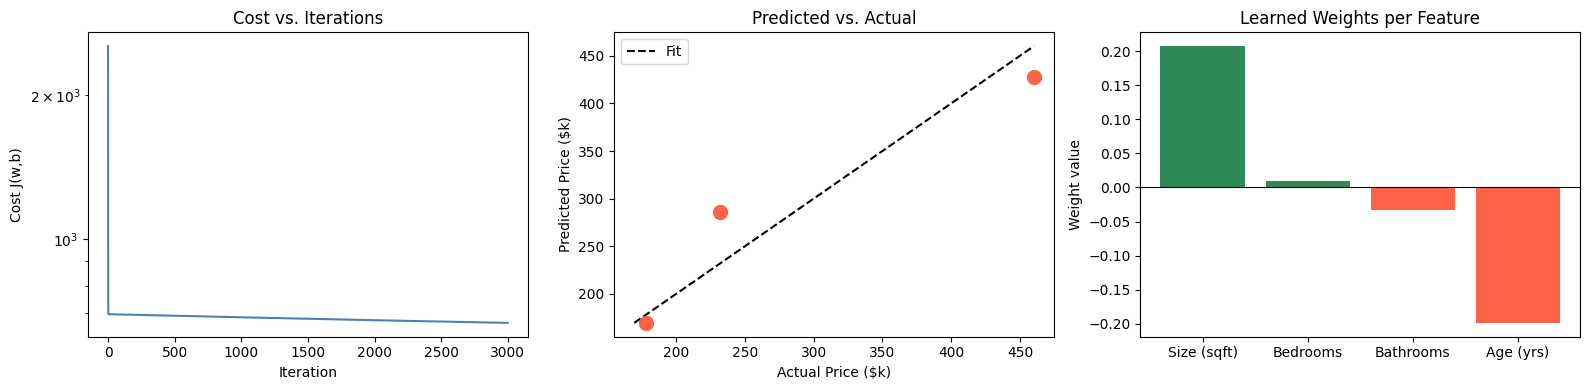

In [55]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Plot 1: Cost curve (learning curve) ---
axes[0].plot(cost_history, color='steelblue')
axes[0].set_title("Cost vs. Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost J(w,b)")
axes[0].set_yscale('log')  # log scale makes early drops visible

# --- Plot 2: Predicted vs Actual ---
y_preds = np.array([predict(X_train[i], w_final, b_final) for i in range(len(X_train))])
axes[1].scatter(y_train, y_preds, color='tomato', s=100, zorder=5)
all_vals = np.concatenate([y_train, y_preds])
axes[1].plot([all_vals.min(), all_vals.max()],
             [all_vals.min(), all_vals.max()], 'k--', label='Fit')
axes[1].set_title("Predicted vs. Actual")
axes[1].set_xlabel("Actual Price ($k)")
axes[1].set_ylabel("Predicted Price ($k)")
axes[1].legend()

# --- Plot 3: Weight magnitudes ---
feature_names = ['Size (sqft)', 'Bedrooms', 'Bathrooms', 'Age (yrs)']
colors = ['seagreen' if v >= 0 else 'tomato' for v in w_final]
axes[2].bar(feature_names, w_final, color=colors)
axes[2].set_title("Learned Weights per Feature")
axes[2].set_ylabel("Weight value")
axes[2].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()